# 01 — The TRIS data that stage 1 consumes

This notebook looks at the **inputs**, not the results: the four archive products, the
beam, the temperature convention, and the GSM2008 template that stands in for a prior
(Blocker 2).  Stage 1's results are in `03_diagnostics.ipynb`.

It also shows where three config decisions come from, so they are not just numbers in a
YAML file:

| config key | decided here |
|---|---|
| `tris.zero_level_sigma_k = 0.5` | the archive's own zero levels, one of which is asymmetric |
| `tris.uncertainty_floor_k = null` | each ring has exactly one row with a 0.000 K error |
| `beam.beam_deg` → `beam.nside_new = 8` | Blocker 1, checked against `bayesian_func.nside_for_beam` |

The convention translation itself (boresight at `RA=LST, dec=lat`, `selfrot=-7`,
Rayleigh–Jeans including the CMB monopole) is **verified numerically** in limTOD's own
walkthrough, `examples/TRIS/tris_limtod_walkthrough.ipynb`. Nothing here re-derives it;
this notebook checks that the pipeline is holding it correctly.

In [2]:
%matplotlib inline
import os
os.environ["TQDM_DISABLE"] = "1"

import sys
import warnings
from pathlib import Path

import numpy as np
import healpy as hp
import matplotlib.pyplot as plt

REPO = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(REPO / "src"))

warnings.filterwarnings("ignore", category=UserWarning)
plt.rcParams.update({"figure.dpi": 110, "font.size": 9, "figure.facecolor": "white"})

from moonrunes.config import load_config
from moonrunes import stage1_tris_maps as stage1

config = load_config(REPO / "configs" / "run_config.yaml")
tris = stage1.import_limtod_tris(config)
ARCHIVE = config.resolve_path("paths.tris_archive_dir")

print("config   ", config.path)
print("archive  ", ARCHIVE)
print("limTOD   ", Path(tris.__file__).resolve())
print()
print("stage 1 decisions in force:")
for key in ("tris.frequencies_mhz", "tris.ref_freq_mhz", "tris.mapmaker",
            "tris.nside", "tris.dec_half_width_deg", "tris.zero_level_sigma_k",
            "tris.prior.template", "tris.prior.relative_sigma",
            "tris.prior.absolute_sigma_k", "tris.solver.method", "tris.solver.rtol"):
    print(f"  {key:32s} {config.get_path(key)}")

config    /Users/user/Documents/Codes/project3/moonrunes/configs/run_config.yaml
archive   /Users/user/Documents/Codes/project3/limTOD/downloads/TRIS
limTOD    /Users/user/Documents/Codes/project3/limTOD/limTOD/tris/__init__.py

stage 1 decisions in force:
  tris.frequencies_mhz             [600, 820]
  tris.ref_freq_mhz                600
  tris.mapmaker                    prior_regularized
  tris.nside                       64
  tris.dec_half_width_deg          45.0
  tris.zero_level_sigma_k          0.5
  tris.prior.template              gsm2008
  tris.prior.relative_sigma        0.1
  tris.prior.absolute_sigma_k      0.3
  tris.solver.method               gmres
  tris.solver.rtol                 1e-12


---
## The four products

Two absolutely-calibrated drift rings (600 and 820 MHz), one point set (2.5 GHz, dropped
— it is not a ring, and the literature review flags its quality), and the beam profile.

In [3]:
ring600 = tris.read_tris_ring(ARCHIVE / "TRIS_absolute_600.txt")
ring820 = tris.read_tris_ring(ARCHIVE / "TRIS_absolute_820.txt")
points  = tris.read_tris_point_set(ARCHIVE / "TRIS_absolute_2500MHz.txt")
cuts    = tris.read_tris_beam_cuts(ARCHIVE / "TRIS_Beam_Profile.txt")
RINGS   = {600: ring600, 820: ring820}

print(f"{'product':18s}{'n':>5}{'nu_eff [MHz]':>14}{'T range [K]':>22}")
for name, obj in (("600 MHz ring", ring600), ("820 MHz ring", ring820),
                  ("2.5 GHz points", points)):
    print(f"{name:18s}{obj.ra_deg.size:5d}{obj.effective_frequency_mhz:14.1f}"
          f"{f'{obj.temperature_k.min():.3f} .. {obj.temperature_k.max():.3f}':>22}")
print(f"{'beam cuts':18s}{cuts.angle_deg.size:5d}"
      f"{'':>14}{f'0 .. {cuts.angle_deg.max():.0f} deg':>22}")

print("\nTwo details a careless reader would destroy:")
print("  RA spacings present:", sorted(set(np.round(np.diff(ring600.ra_deg), 9))),
      "deg  <- NOT a uniform 3 deg grid")
print("  rows with a 0.000 K statistical error:",
      int((ring600.statistical_uncertainty_k == 0).sum()), "(600) and",
      int((ring820.statistical_uncertainty_k == 0).sum()), "(820)")
print("  -> tris.uncertainty_floor_k = null means stage 1 uses each ring's smallest")
print("     strictly positive error instead:",
      {f: float(r.statistical_uncertainty_k[r.statistical_uncertainty_k > 0].min())
       for f, r in RINGS.items()}, "K")

product               n  nu_eff [MHz]           T range [K]
600 MHz ring        120         600.5       9.390 .. 28.193
820 MHz ring        120         817.8       5.357 .. 13.574
2.5 GHz points        6        2427.8        2.329 .. 2.886
beam cuts            55                        0 .. 176 deg

Two details a careless reader would destroy:
  RA spacings present: [np.float64(2.75), np.float64(3.0), np.float64(3.25)] deg  <- NOT a uniform 3 deg grid
  rows with a 0.000 K statistical error: 1 (600) and 1 (820)
  -> tris.uncertainty_floor_k = null means stage 1 uses each ring's smallest
     strictly positive error instead: {600: 0.004, 820: 0.004} K


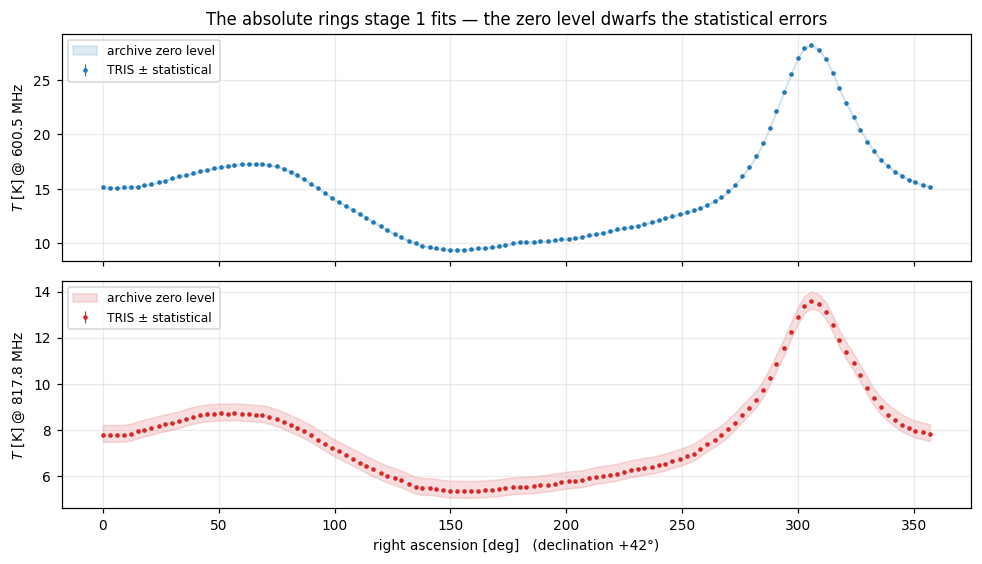

In [4]:
fig, axes = plt.subplots(2, 1, figsize=(9, 5.2), sharex=True)
for ax, (freq, ring), colour in zip(axes, RINGS.items(), ("tab:blue", "tab:red")):
    ax.errorbar(ring.ra_deg, ring.temperature_k, yerr=ring.statistical_uncertainty_k,
                fmt=".", ms=4, lw=0.8, color=colour, label="TRIS ± statistical")
    zero = ring.zero_level_uncertainty_k
    lo, hi = (zero, zero) if np.isscalar(zero) else (zero.negative_k, zero.positive_k)
    ax.fill_between(ring.ra_deg, ring.temperature_k - lo, ring.temperature_k + hi,
                    color=colour, alpha=0.15, label="archive zero level")
    ax.set_ylabel(f"$T$ [K] @ {ring.effective_frequency_mhz:.1f} MHz")
    ax.legend(loc="upper left", fontsize=8)
    ax.grid(alpha=0.25)
axes[1].set_xlabel("right ascension [deg]   (declination +42°)")
axes[0].set_title("The absolute rings stage 1 fits — the zero level dwarfs the "
                  "statistical errors")
fig.tight_layout()

### Where `tris.zero_level_sigma_k = 0.5` comes from

The published zero level is one fully correlated offset. Stage 1 carries it as an
explicit nuisance parameter with a Gaussian prior — exactly equivalent to the rank-1
noise term, but it also hands back the fitted offset.

The catch is that the 820 MHz zero level is **asymmetric**, and limTOD deliberately
refuses to symmetrise it for you. A single Gaussian width has to cover both rings without
claiming a precision the 820 MHz ring does not have.

In [5]:
chosen = float(config.require("tris.zero_level_sigma_k"))
print(f"{'ring':>6}  {'archive zero level':<34}{'covered by 0.5 K?':>18}")
for freq, ring in RINGS.items():
    z = ring.zero_level_uncertainty_k
    text = (f"{float(z):.3f} K (symmetric)" if np.isscalar(z)
            else f"+{z.positive_k:.3f} / -{z.negative_k:.3f} K (ASYMMETRIC)")
    widest = float(z) if np.isscalar(z) else max(z.positive_k, z.negative_k)
    print(f"{freq:6d}  {text:<34}{'yes' if chosen >= widest else 'NO':>18}")
print(f"\ntris.zero_level_sigma_k = {chosen} K: one symmetric prior wide enough for both,")
print("recorded as a decision rather than silently symmetrising +0.430/-0.300.")

  ring  archive zero level                 covered by 0.5 K?
   600  0.066 K (symmetric)                              yes
   820  +0.430 / -0.300 K (ASYMMETRIC)                   yes

tris.zero_level_sigma_k = 0.5 K: one symmetric prior wide enough for both,
recorded as a decision rather than silently symmetrising +0.430/-0.300.


---
## The temperature convention

The archive never states Rayleigh–Jeans vs thermodynamic, nor whether the CMB monopole is
included. The two rings share an RA grid, so the Galactic spectral index between them is a
clean per-sample discriminator: only one treatment gives synchrotron. Stage 1's template
is built with `to_tris_temperature_convention`, so this has to come out right or every
kelvin downstream is wrong.

CMB monopole: thermodynamic 2.72548 K, RJ-equivalent 2.7111 K at 600.5 MHz
treatment                        min   median     max
CMB monopole left in           -2.39    -2.10   -1.81
CMB monopole removed (RJ)      -3.12    -2.91   -2.63

Synchrotron is -2.5..-3.1. Only the second row is physical, so TRIS
temperatures are Rayleigh-Jeans and INCLUDE the CMB monopole.


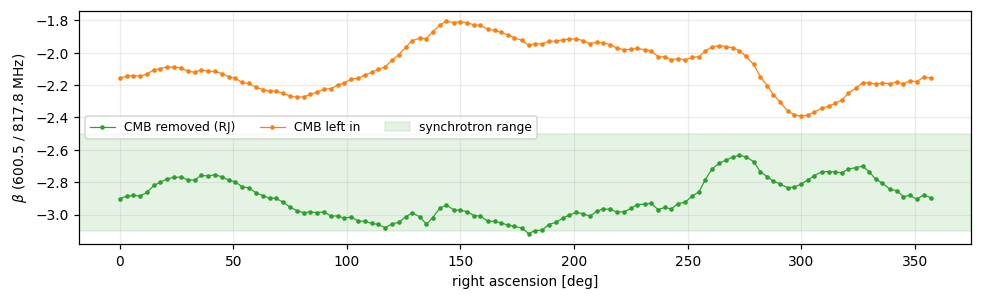

In [6]:
nu6, nu8 = ring600.effective_frequency_mhz, ring820.effective_frequency_mhz
assert np.allclose(ring600.ra_deg, ring820.ra_deg)

with_cmb = np.log(ring600.temperature_k / ring820.temperature_k) / np.log(nu6 / nu8)
without = tris.galactic_spectral_index(ring600.temperature_k, nu6,
                                       ring820.temperature_k, nu8)

print(f"CMB monopole: thermodynamic {tris.CMB_T0_K:.5f} K, "
      f"RJ-equivalent {tris.cmb_monopole_rj_k(nu6):.4f} K at {nu6} MHz")
print(f"{'treatment':<28}{'min':>8}{'median':>9}{'max':>8}")
print(f"{'CMB monopole left in':<28}{with_cmb.min():8.2f}{np.median(with_cmb):9.2f}"
      f"{with_cmb.max():8.2f}")
print(f"{'CMB monopole removed (RJ)':<28}{without.min():8.2f}{np.median(without):9.2f}"
      f"{without.max():8.2f}")
print("\nSynchrotron is -2.5..-3.1. Only the second row is physical, so TRIS")
print("temperatures are Rayleigh-Jeans and INCLUDE the CMB monopole.")

fig, ax = plt.subplots(figsize=(9, 2.8))
ax.plot(ring600.ra_deg, without, ".-", ms=4, lw=0.8, color="tab:green",
        label="CMB removed (RJ)")
ax.plot(ring600.ra_deg, with_cmb, ".-", ms=4, lw=0.8, color="tab:orange",
        label="CMB left in")
ax.axhspan(-3.1, -2.5, color="tab:green", alpha=0.12, label="synchrotron range")
ax.set_xlabel("right ascension [deg]")
ax.set_ylabel(r"$\beta$ (600.5 / 817.8 MHz)")
ax.legend(fontsize=8, ncol=3); ax.grid(alpha=0.25)
fig.tight_layout()

---
## The beam, and Blocker 1

Stage 1 builds the beam from the archive's own principal-plane cuts, never a Gaussian:
the cuts run to 176° and −49 dB, and the Gaussian has no shoulders at all. The
below-horizon response is small but not negligible against the published 0.066 K
systematic, which is why the horizon mask is on.

Blocker 1 is the separate question of what beam width `bayesian_skymap` is told about
downstream. `beam.beam_deg` is the mean of the two principal planes (its forward model is
azimuthally symmetric, so an asymmetric beam cannot be represented), and the cell below
runs the fork's own heuristic to confirm the pinned `beam.nside_new`.

archive table HPBW: E 19.155 deg, H 23.366 deg  (the ring header's '18 deg' is -6.0% off)

Blocker 1 — beam.beam_deg = 21.2605 deg (mean of E and H = 21.2603)
  bayesian_func.nside_for_beam -> 8, config pins 8  -> consistent


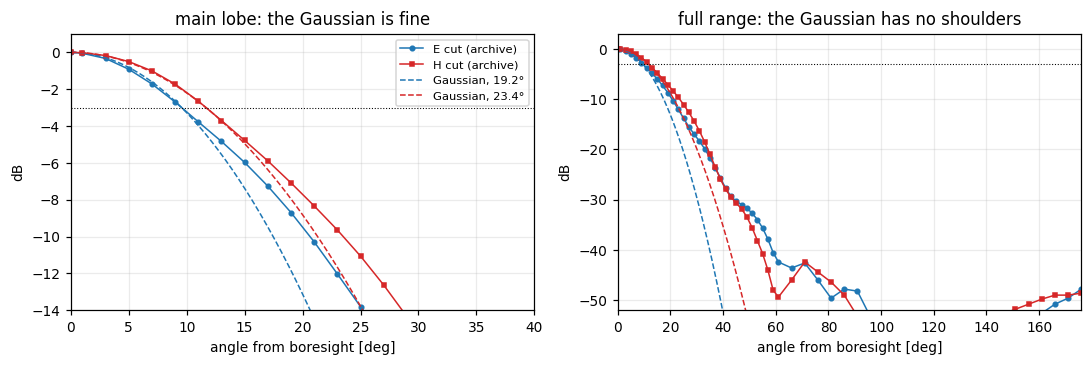

In [14]:
e_fwhm, h_fwhm = cuts.half_power_full_width_deg()
half_power_db = -10 * np.log10(2)
print(f"archive table HPBW: E {e_fwhm:.3f} deg, H {h_fwhm:.3f} deg  "
      f"(the ring header's '18 deg' is {100*(18/e_fwhm-1):+.1f}% off)")

check = stage1._check_beam_against_bayesian_skymap(config)
print(f"\nBlocker 1 — beam.beam_deg = {check['beam_deg']:.4f} deg "
      f"(mean of E and H = {(e_fwhm+h_fwhm)/2:.4f})")
print(f"  bayesian_func.nside_for_beam -> {check['nside_new_from_bayesian_func']}, "
      f"config pins {check['nside_new_pinned']}  -> consistent")

fig, axes = plt.subplots(1, 2, figsize=(10, 3.4))
fine = np.linspace(0, 60, 400)
for ax, span in zip(axes, [(0, 40, -14, 1), (0, 176, -52, 3)]):
    ax.plot(cuts.angle_deg, cuts.e_plane_db, "o-", ms=3, lw=1, color="tab:blue",
            label="E cut (archive)")
    ax.plot(cuts.angle_deg, cuts.h_plane_db, "s-", ms=3, lw=1, color="tab:red",
            label="H cut (archive)")
    ax.plot(fine, half_power_db * (2 * fine / e_fwhm) ** 2, "--", color="tab:blue",
            lw=1, label=f"Gaussian, {e_fwhm:.1f}°")
    ax.plot(fine, half_power_db * (2 * fine / h_fwhm) ** 2, "--", color="tab:red",
            lw=1, label=f"Gaussian, {h_fwhm:.1f}°")
    ax.axhline(half_power_db, color="k", lw=0.7, ls=":")
    ax.set_xlim(span[0], span[1]); ax.set_ylim(span[2], span[3])
    ax.set_xlabel("angle from boresight [deg]"); ax.set_ylabel("dB")
    ax.grid(alpha=0.25)
axes[0].legend(fontsize=7.5)
axes[0].set_title("main lobe: the Gaussian is fine")
axes[1].set_title("full range: the Gaussian has no shoulders")
fig.tight_layout()

In [15]:
NSIDE_BEAM = 128
cut_beam = tris.tris_cut_beam_map(cuts, nside=NSIDE_BEAM, normalization="peak")
gauss_beam = tris.approximate_tris_gaussian_beam_map(nside=NSIDE_BEAM,
                                                     normalization="peak")
theta = np.rad2deg(hp.pix2ang(NSIDE_BEAM, np.arange(hp.nside2npix(NSIDE_BEAM)))[0])
order = np.argsort(theta)
mask = tris.tris_horizon_mask(NSIDE_BEAM)

print(f"{'beam':<16}{'θ<10°':>9}{'θ<20°':>9}{'θ<30°':>9}{'θ<45°':>9}"
      f"{'below horizon':>16}{'ground @300K':>14}")
for name, beam in (("Gaussian", gauss_beam), ("archive cuts", cut_beam)):
    weight = beam / beam.sum()
    cumulative = np.cumsum(weight[order])
    below = float(weight[mask == 0].sum())
    cums = [cumulative[theta[order] < lim][-1] for lim in (10, 20, 30, 45)]
    print(f"{name:<16}" + "".join(f"{c:9.4f}" for c in cums)
          + f"{below:16.2e}{below*300:14.3f} K")
print("\nbeam.apply_horizon_mask =", config.require("beam.apply_horizon_mask"),
      "-- the cut beam's ground pickup is comparable to the 0.066 K systematic.")

beam                θ<10°    θ<20°    θ<30°    θ<45°   below horizon  ground @300K
Gaussian           0.4917   0.9260   0.9965   1.0000        2.77e-20         0.000 K
archive cuts       0.3809   0.8107   0.9660   0.9970        1.16e-04         0.035 K

beam.apply_horizon_mask = True -- the cut beam's ground pickup is comparable to the 0.066 K systematic.


---
## The prior template (Blocker 2's substitute)

There is no true sky for real data, and Berkhuijsen (1972) is not in hand yet, so
**GSM2008 is used as both the prior template and the reference "truth"**. That is
circular by construction and stage 1's manifest records it as such.

What makes it still worth doing is the number below. Forward-modelling GSM2008 through
the same geometry and beam that stage 1 uses gives a *measured* offset against the
absolutely-calibrated rings — and stage 1's fitted zero level should come out at
roughly that value, because a tight per-pixel prior leaves the nuisance offset as the
only place a template error can go. That correspondence is the real check on stage 1,
and `03_diagnostics.ipynb` makes it.

In [16]:
from limTOD import generate_TOD_sky

NSIDE_SKY = int(config.require("tris.nside"))
horizon = tris.tris_horizon_mask(NSIDE_SKY)
beam_sky = tris.tris_cut_beam_map(cuts, nside=NSIDE_SKY, normalization="peak")

templates, profiles, offsets = {}, {}, {}
for freq, ring in RINGS.items():
    nu = ring.effective_frequency_mhz
    templates[freq] = stage1.gsm2008_template(nu, NSIDE_SKY)   # the stage 1 template
    g = tris.tris_zenith_geometry(ring.ra_deg)
    profiles[freq] = generate_TOD_sky(beam_sky, templates[freq], g.lst_deg,
                                      g.latitude_deg, g.azimuth_deg, g.elevation_deg,
                                      g.selfrot_deg, normalize_beam=True,
                                      horizontal_mask=horizon)
    offsets[freq] = profiles[freq] - ring.temperature_k

print(f"{'nu [MHz]':>9}{'mean GSM2008 - TRIS':>22}{'scatter rms':>13}{'max |Δ|':>10}")
for freq, d in offsets.items():
    print(f"{freq:9d}{d.mean():+22.3f}{d.std():13.3f}{np.abs(d).max():10.3f}")
print("\nGSM2008 runs COLD against the absolute rings. Stage 1's fitted zero level")
print("should land near the negative of these means:",
      {f: round(-float(d.mean()), 2) for f, d in offsets.items()}, "K")

 nu [MHz]   mean GSM2008 - TRIS  scatter rms   max |Δ|
      600                -1.919        0.476     3.946
      820                -0.563        0.271     1.427

GSM2008 runs COLD against the absolute rings. Stage 1's fitted zero level
should land near the negative of these means: {600: 1.92, 820: 0.56} K


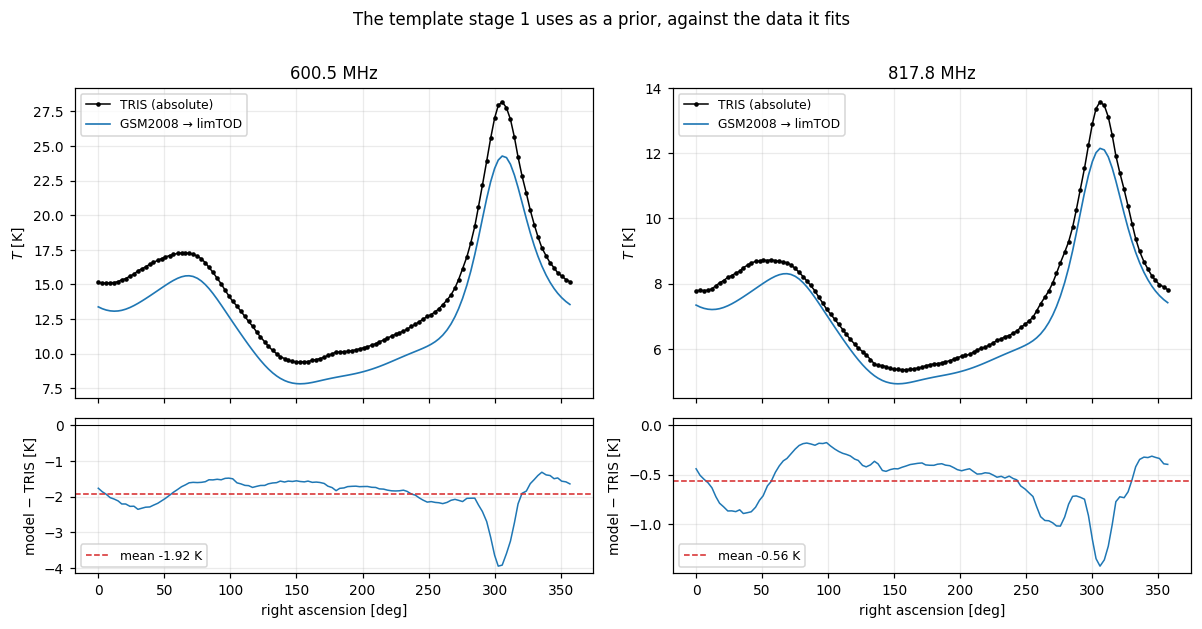

In [17]:
fig, axes = plt.subplots(2, 2, figsize=(11, 5.6), sharex="col",
                         gridspec_kw={"height_ratios": [2, 1]})
for col, (freq, ring) in enumerate(RINGS.items()):
    top, bot = axes[0, col], axes[1, col]
    top.plot(ring.ra_deg, ring.temperature_k, "k.-", ms=4, lw=1.0,
             label="TRIS (absolute)")
    top.plot(ring.ra_deg, profiles[freq], lw=1.1, color="tab:blue",
             label="GSM2008 → limTOD")
    bot.plot(ring.ra_deg, offsets[freq], lw=1.0, color="tab:blue")
    bot.axhline(0, color="k", lw=0.7)
    bot.axhline(offsets[freq].mean(), color="tab:red", ls="--", lw=1,
                label=f"mean {offsets[freq].mean():+.2f} K")
    top.set_ylabel("$T$ [K]"); bot.set_ylabel("model − TRIS [K]")
    bot.set_xlabel("right ascension [deg]")
    top.set_title(f"{ring.effective_frequency_mhz:.1f} MHz")
    top.legend(fontsize=8); bot.legend(fontsize=8)
    top.grid(alpha=0.25); bot.grid(alpha=0.25)
fig.suptitle("The template stage 1 uses as a prior, against the data it fits", y=1.01)
fig.tight_layout()

---
## Pixelisation: what 120 samples can and cannot support

The beam is 19.2° × 23.4°, and a 120-sample ring measures roughly 15 independent numbers
because the beam suppresses harmonics above $m\sim8$. The table below is the honest
accounting of what each candidate `tris.nside` asks for.

`tris.nside` is the grid stage 1 *solves* on; `beam.nside_new` is the grid stage 3 hands
to `bayesian_skymap`. They do not have to match — stage 3 degrades — but the ratio of
pixels to samples is what decides how much of the answer is prior rather than data.

In [18]:
working = int(config.require("tris.nside"))
target = int(config.require("beam.nside_new"))
half_width = float(config.require("tris.dec_half_width_deg"))
dec = tris.tris_zenith_geometry(ring600.ra_deg).boresight_dec_deg
n_samples = ring600.ra_deg.size

print(f"{'nside':>7}{'pixel [deg]':>13}{'E FWHM/pix':>12}{'H FWHM/pix':>12}"
      f"{'pixels in band':>16}{'samples/pixel':>15}   note")
for nside in (4, 8, 16, 32, 64):
    pixel_deg = hp.nside2resol(nside, arcmin=True) / 60
    n_band = tris.tris_ring_pixels(nside, dec_deg=dec,
                                   half_width_deg=half_width).size
    note = []
    if nside == working:
        note.append("tris.nside (stage 1 solves here)")
    if nside == target:
        note.append("beam.nside_new (stage 3 target)")
    print(f"{nside:7d}{pixel_deg:13.2f}{e_fwhm/pixel_deg:12.2f}{h_fwhm/pixel_deg:12.2f}"
          f"{n_band:16d}{n_samples/n_band:15.4f}   {', '.join(note)}")
print(f"\nThe ring has {n_samples} samples and about 15 independent numbers in them.")
print("At every nside in this table the pixels outnumber the data, so the map is")
print("prior-dominated by construction -- 03_diagnostics.ipynb measures by how much.")

  nside  pixel [deg]  E FWHM/pix  H FWHM/pix  pixels in band  samples/pixel   note
      4        14.66        1.31        1.59             104         1.1538   
      8         7.33        2.61        3.19             400         0.3000   beam.nside_new (stage 3 target)
     16         3.66        5.23        6.38            1632         0.0735   
     32         1.83       10.45       12.75            6460         0.0186   
     64         0.92       20.91       25.51           25704         0.0047   tris.nside (stage 1 solves here)

The ring has 120 samples and about 15 independent numbers in them.
At every nside in this table the pixels outnumber the data, so the map is
prior-dominated by construction -- 03_diagnostics.ipynb measures by how much.


---
## Summary — what stage 1 is handed

* **Two absolute rings**, 120 samples each on a shared, non-uniform RA grid, each with one
  0.000 K row that forces an uncertainty floor.
* **A zero level** that dwarfs the statistical errors and is asymmetric at 820 MHz —
  carried as a nuisance parameter with a 0.5 K symmetric prior, recorded as a decision.
* **A beam from the archive's own cuts**, with real below-horizon response that the
  horizon mask removes; its E/H mean feeds Blocker 1's `nside_new = 8`, confirmed against
  `bayesian_func.nside_for_beam`.
* **Rayleigh–Jeans temperatures including the CMB monopole**, settled by the physics
  rather than a header.
* **GSM2008 as prior *and* truth** (Blocker 2), measured here as ~1.9 K cold at 600 MHz
  and ~0.6 K cold at 820 MHz. Stage 1's fitted zero level should reproduce those numbers,
  and if it does, the offset is a measurement of GSM2008 — not of the archive's zero point.

Next: `03_diagnostics.ipynb` for the stage 1 results.
`02_build_berkhijsen_prior.ipynb` is stage 2 work and is still empty.